## Checking if bayfai package was built

In [8]:
try:
    import bayfai
except ModuleNotFoundError as e:
    raise ModuleNotFoundError(
        "bayfai is not installed.\n"
        "Run `pip install -e .` inside the BayFAI root directory."
    ) from e

## Imports

In [9]:
from bayfai.fake_detector import FakeDetector
%matplotlib widget

## Setup

Converted psana .data geometry file /sdf/group/lcls/ds/ana/sw/conda2/rel/lcls2_020426/psana/psana/pscalib/geometry/data/geometry-def-jungfrau16M.data to PyFAI Detector.


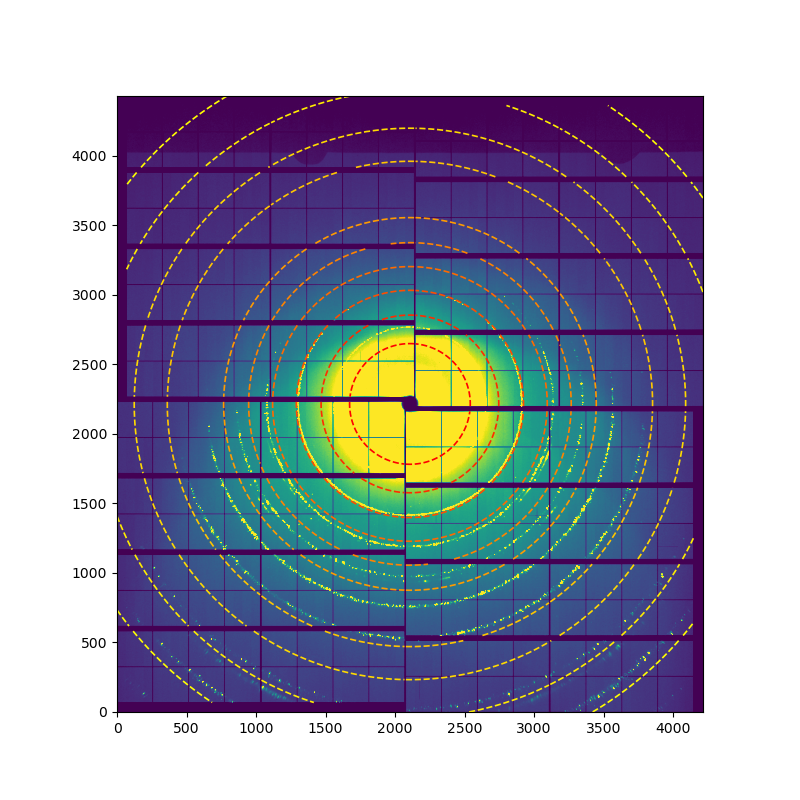

In [15]:
# Define experiment set up
exp = 'mfx101211025'                          # Fill this line
run = 23                                     # Fill this line
detname = 'jungfrau'                         # Fill this line
calibrant = 'LaB6'                           # Fill this line
powder_path = f"/sdf/data/lcls/ds/{exp[:3]}/{exp}/results/bayfai/powder/{exp}_Run{run:04d}.h5"   # Fill this line

fitter = FakeDetector(exp, run, detname, calibrant, powder_path)

## Image Settings and Geometry Fit

In [16]:
fitter.show_powder()

## Azimuthal Integration Check

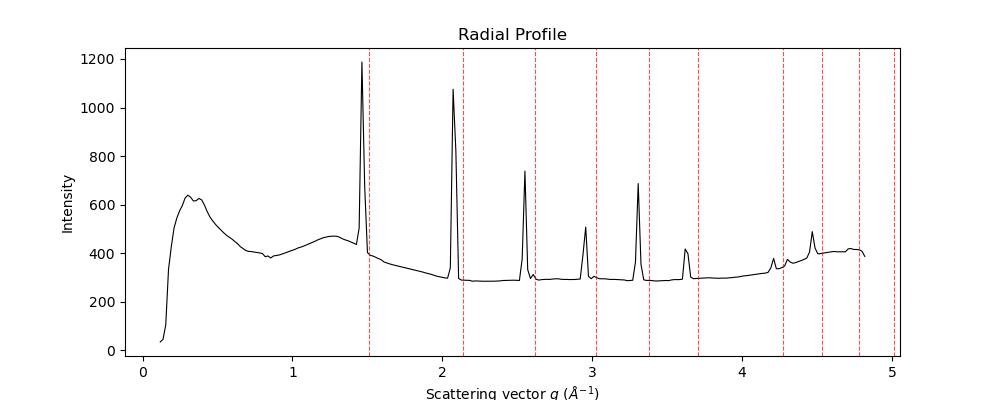

In [17]:
fitter.integrate_detector()

## Refinement Step

In [18]:
fitter.refine_geometry()

Final Geometry Score: 1.741869745730878e-05
Distance (m): 0.126285870058628
X-shift (m): -0.0005
Y-shift (m): 6.906627641863388e-05
Rx (rad): 0.0003973678620626776
Ry (rad): 0.0014405696373851608
Rz (rad): 0.0


## Azimuthal Integration Check

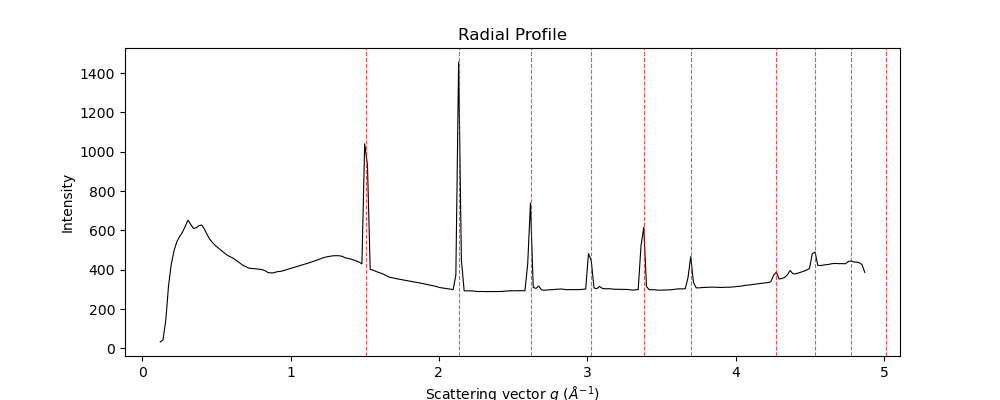

In [19]:
fitter.integrate_detector()

## Writing out new geometries

In [7]:
outfile = f"/sdf/data/lcls/ds/{exp[:3]}/{exp}/results/bayfai/lute_output/geom/{run}-end.data"
calibrated_detector = fitter.update_geometry(outfile)

ERROR:pyFAI.detectors._common:Factory: Left-over config parameters in detector Jungfrau16M: {'pixel1': 7.5e-05, 'pixel2': 7.5e-05, 'max_shape': [16384, 1024], 'orientation': 3}
ERROR:pyFAI.detectors._common:Factory: Left-over config parameters in detector Jungfrau16M: {'pixel1': 7.5e-05, 'pixel2': 7.5e-05, 'max_shape': [16384, 1024], 'orientation': 3}


## Push to Database -- ONLY FOR LCLS-II detectors !!!

In [ ]:
fitter.push_to_db(outfile)

In [8]:
####################################################################################################################